# EVo: a worked example

EVo models volcanic gas speciation and volume as magma rises from depth toward the surface. Given a magma composition, temperature, fO2, and dissolved volatile contents, EVo tracks how CO2, H2O, SO2, H2S and other species partition between the melt and an exsolving gas phase at each pressure step.

This notebook covers:
1. Setting up the magma composition and run parameters
2. Running EVo
3. Understanding the output columns
4. Using built-in plot functions
5. Building a custom plot

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import evo
import evo.plots as evoplots

## 1. Define the magma composition

The dry (volatile-free) major element composition is provided as a `pd.Series` of oxide weight percents. The example below is basaltic; other example compositions are in `input_files/chem.yaml`.

In [2]:
composition = pd.Series({
    "SIO2":  47.95,
    "TIO2":   1.67,
    "AL2O3": 17.32,
    "FEO":   10.24,
    "MNO":    0.17,
    "MGO":    5.76,
    "CAO":   10.93,
    "NA2O":   3.45,
    "K2O":    1.99,
    "P2O5":   0.51,
})

## 2. Configure the run

All run settings are passed as a second `pd.Series`. The key options are:

| Parameter | Description |
|---|---|
| `GAS_SYS` | Volatile system to model: `oh`, `coh`, `soh`, `cohs`, `cohsn` |
| `FIND_SATURATION` | If `True`, EVo finds the volatile saturation pressure and decompresses from there |
| `FE_SYSTEM` | If `True`, fO2 is buffered by melt Fe2+/Fe3+ exchange |
| `FO2_buffer` / `FO2_buffer_START` | Rock buffer (`IW`, `FMQ`, `NNO`) and log-unit offset |
| `T_START` | Temperature in Kelvin |

The volatile inputs tell EVo the initial dissolved content of the melt. With `FIND_SATURATION = True`, these values determine the saturation pressure — no need to set `P_START`. See `input_files/env.yaml` for the full list of options and defaults.

In [11]:
# Set up fixed model parameters

model = {"COMPOSITION": "basalt",
        "FIND_SATURATION": True,
        "GAS_SYS": "cohs",
        "FE_SYSTEM": True,
        "FO2_buffer_SET": True,
        "FH2_SET": False,
        "WTH2O_SET": True,
        "WTCO2_SET": True,
        "SULFUR_SET": True}

# Then merge with the input parameters for use with EVo.

# Starting conditions
fo2_buffer  = "FMQ"  # reference buffer (IW, FMQ or NNO)
dfo2        = 0      # offset from buffer in log units
temp_k      = 1473   # temperature, K
h2o_wt_perc = 2.0    # dissolved H2O in the melt, wt%
co2_wt_perc = 0.1   # dissolved CO2 in the melt, wt%
s_ppm       = 3000   # dissolved S in the melt, ppm

env = pd.Series(model | {
    'FO2_buffer': fo2_buffer,
    'FO2_buffer_START': dfo2,
    'T_START': temp_k,
    # Volatile inputs as melt wt fractions (EVo uses wt fraction internally)
    'WTH2O_START': h2o_wt_perc / 100,
    'WTCO2_START': co2_wt_perc / 100,
    'SULFUR_START': s_ppm / 1e6
})

## 3. Run EVo

`evo.run_evo()` returns a DataFrame for convenient analysis.

In [12]:
df = evo.run_evo(composition, env)
df

Reading in from:
Output file: None 

Set parameters:
COMPOSITION = basalt
RUN_TYPE = closed
SINGLE_STEP = False
FIND_SATURATION = True
GAS_SYS = COHS
FE_SYSTEM = True
OCS = False
S_SAT_WARN = False
T_START = 1473.0
P_START = 3000.0
P_STOP = 1.0
DP_MIN = 1.0
DP_MAX = 100.0
MASS = 100.0
WgT = 0.001
LOSS_FRAC = 0.99
DENSITY_MODEL = spera2000
FO2_MODEL = kc1991
FMQ_MODEL = frost1991
H2O_MODEL = burguisser2015
H2_MODEL = gaillard2003
C_MODEL = burguisser2015
CO_MODEL = None
CH4_MODEL = None
SULFIDE_CAPACITY = oneill2020
SULFATE_CAPACITY = nash2019
SCSS = liu2007
N_MODEL = libourel2003
FO2_buffer_SET = True
FO2_buffer = FMQ
FO2_buffer_START = 0.0
FO2_SET = True
FO2_START = 0.0
FH2_SET = False
FH2_START = 0.24
FH2O_SET = False
FH2O_START = 1000.0
FCO2_SET = False
FCO2_START = 0.01
ATOMIC_MASS_SET = False
ATOMIC_H = 550.0
ATOMIC_C = 200.0
ATOMIC_S = 4000.0
ATOMIC_N = 10.0
WTH2O_SET = True
WTH2O_START = 0.02
WTCO2_SET = True
WTCO2_START = 0.001
SULFUR_SET = True
SULFUR_START = 0.003
NITROGEN_SE

,P,FMQ,fo2,F,rho_bulk,rho_melt,Exsol_vol%,Gas_wt,mol_mass,mH2O,...,S2-_melt,S6+_melt,Stot_melt,N_melt,tot_H,tot_C,tot_O_gas,tot_O,tot_S,tot_N
0,1612.465912,0.000000,6.573518e-09,0.097589,2691.920650,2691.920798,0.000006,0.000001,0.036993,0.245405,...,0.180800,0.119200,0.300000,0.0,2239.340454,272.670768,18489.128877,47925.055153,3000.000199,0.0
0,1612.000000,0.000042,6.573630e-09,0.097592,2563.510823,2563.515048,0.000208,0.000040,0.036991,0.245475,...,0.180786,0.119214,0.299999,0.0,2239.340454,272.670768,18489.122645,47925.055153,3000.000199,0.0
1,1512.000000,0.000614,6.470078e-09,0.097724,2560.908089,2562.194301,0.062320,0.010981,0.036551,0.262105,...,0.179863,0.119899,0.299762,0.0,2239.340454,272.670768,18486.600099,47925.055153,3000.000199,0.0
2,1412.000000,0.000641,6.360171e-09,0.097833,2558.044141,2560.881695,0.135196,0.021967,0.036050,0.280962,...,0.179050,0.120427,0.299477,0.0,2239.340454,272.670768,18484.523626,47925.055153,3000.000199,0.0
3,1312.000000,0.000832,6.254495e-09,0.097950,2554.836691,2559.587137,0.222619,0.033120,0.035479,0.302517,...,0.178153,0.120974,0.299127,0.0,2239.340454,272.670768,18482.297705,47925.055153,3000.000199,0.0
4,1212.000000,0.001259,6.153905e-09,0.098078,2551.156510,2558.319428,0.330231,0.044608,0.034821,0.327392,...,0.177140,0.121550,0.298691,0.0,2239.340454,272.670768,18479.862361,47925.055153,3000.000199,0.0
5,1112.000000,0.002027,6.059704e-09,0.098222,2546.799758,2557.092169,0.466905,0.056689,0.034053,0.356415,...,0.175963,0.122166,0.298129,0.0,2239.340454,272.670768,18477.126808,47925.055153,3000.000199,0.0
6,1012.000000,0.003307,5.973979e-09,0.098389,2541.426960,2555.927572,0.647364,0.069779,0.033148,0.390686,...,0.174541,0.122840,0.297381,0.0,2239.340454,272.670768,18473.947236,47925.055153,3000.000199,0.0
7,912.000000,0.005384,5.900280e-09,0.098593,2534.432697,2554.864478,0.897777,0.084600,0.032067,0.431691,...,0.172742,0.123601,0.296343,0.0,2239.340454,272.670768,18470.081167,47925.055153,3000.000199,0.0
8,812.000000,0.008761,5.844961e-09,0.098855,2524.639869,2553.976703,1.268813,0.102512,0.030759,0.481401,...,0.170324,0.124490,0.294814,0.0,2239.340454,272.670768,18465.099914,47925.055153,3000.000199,0.0


## 4. Understanding the output

The output DataFrame contains one row per pressure step. With `FIND_SATURATION = True` the first row records conditions at the saturation pressure, and subsequent rows follow decompression. The columns fall into several groups:

| Column(s) | Units | Description |
|---|---|---|
| `P` | bar | Pressure |
| `FMQ` (or `NNO` / `IW`) | log units | fO2 relative to buffer |
| `fo2` | bar | Absolute oxygen fugacity |
| `F` | ratio | Molar Fe2O3/FeO in melt |
| `Gas_wt` | wt% | Exsolved gas weight fraction |
| `Exsol_vol%` | vol% | Exsolved gas volume fraction |
| `mH2O`, `mCO2`, `mSO2`, … | mol fraction | Gas phase speciation |
| `wH2O`, `wCO2`, `wSO2`, … | wt fraction | Gas phase speciation |
| `fH2O`, `fCO2`, `fSO2`, … | bar | Species fugacities |
| `mCO2/SO2`, `mH2S/SO2`, … | — | Molar ratios of gas species |
| `H2O_melt`, `CO2_melt`, `S2-_melt`, … | wt% | Volatiles remaining dissolved in melt |
| `Stot_melt` | wt% | Total dissolved S (S2- + S6+) |
| `tot_H`, `tot_C`, `tot_S`, … | ppm | Total elemental budget (use to check conservation) |
| `rho_melt`, `rho_bulk` | kg/m³ | Melt and bulk densities |

In [5]:
# Pressure, gas fraction, major gas species, and melt residuals
df[["P", "Gas_wt", "Exsol_vol%", "mH2O", "mCO2", "mSO2", "mH2S", "H2O_melt", "CO2_melt", "Stot_melt"]]

,P,Gas_wt,Exsol_vol%,mH2O,mCO2,mSO2,mH2S,H2O_melt,CO2_melt,Stot_melt
0,4353.679694,0.000001,0.000002,0.078515,0.883977,0.002055,0.003051,2.000000,0.500000,0.300000
0,4353.000000,0.000075,0.000133,0.078527,0.883965,0.002055,0.003051,1.999997,0.499928,0.300000
1,4253.000000,0.021522,0.038891,0.080881,0.881359,0.002102,0.003187,1.999150,0.479123,0.299893
2,4153.000000,0.042372,0.078488,0.083341,0.878617,0.002148,0.003333,1.998320,0.458952,0.299783
3,4053.000000,0.062704,0.119138,0.085916,0.875751,0.002195,0.003488,1.997457,0.439341,0.299667
4,3953.000000,0.082533,0.160958,0.088611,0.872752,0.002245,0.003652,1.996557,0.420278,0.299546
5,3853.000000,0.101877,0.204076,0.091438,0.869611,0.002297,0.003826,1.995617,0.401749,0.299419
6,3753.000000,0.120752,0.248637,0.094405,0.866316,0.002351,0.004012,1.994634,0.383740,0.299286
7,3653.000000,0.139174,0.294802,0.097522,0.862858,0.002408,0.004209,1.993604,0.366241,0.299145
8,3553.000000,0.157162,0.342751,0.100801,0.859224,0.002468,0.004418,1.992522,0.349237,0.298996


## 5. Built-in plots

`evo.plots` provides four functions that each take the output DataFrame and return a matplotlib Figure. All plots use pressure on the y-axis (inverted, so the surface is at the top of the plot).

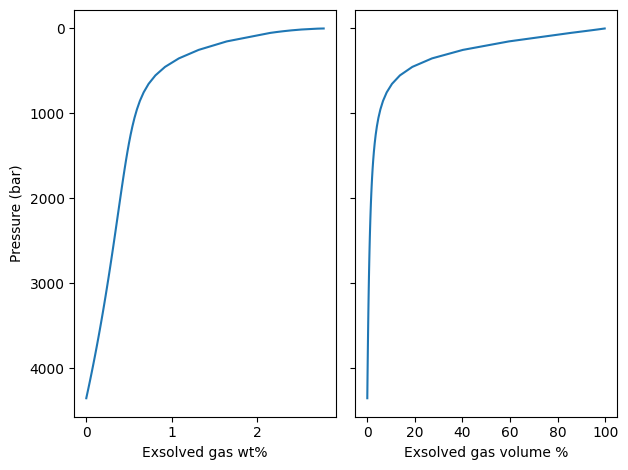

In [6]:
# Exsolved gas weight fraction and volume fraction vs pressure
fig = evoplots.plot_gasfraction(df)
plt.tight_layout()
plt.show()

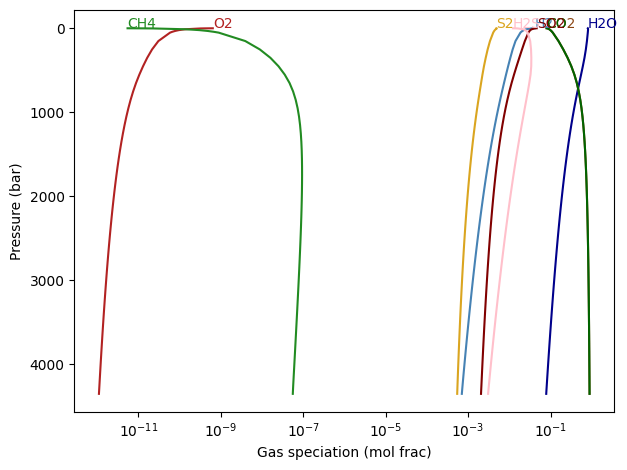

In [7]:
# Gas phase speciation (mole fractions) vs pressure
fig = evoplots.plot_gasspecies_mol(df)
plt.tight_layout()
plt.show()

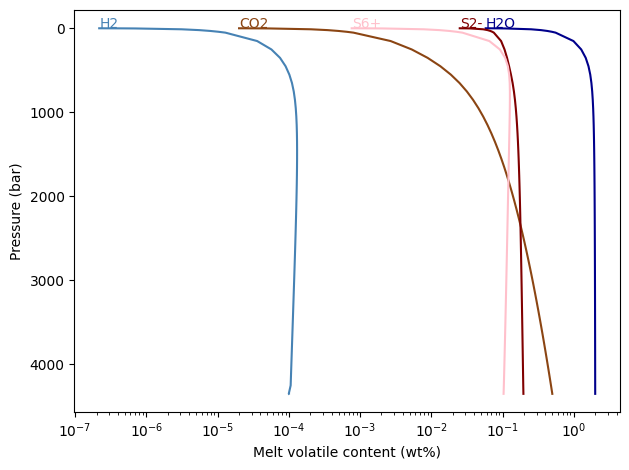

In [8]:
# Dissolved volatile content remaining in the melt vs pressure
fig = evoplots.plot_meltspecies(df)
plt.tight_layout()
plt.show()

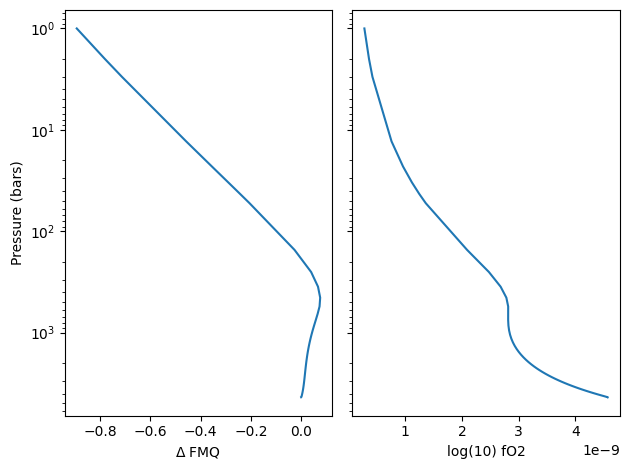

In [9]:
# fO2 evolution: delta-FMQ and absolute log fO2 vs pressure
fig = evoplots.plot_fo2FMQ(df)
plt.tight_layout()
plt.show()

## 6. Custom analysis

The DataFrame can be used directly for any custom analysis. Here we plot H2S/SO2 to show how it evolves during decompression alongside the fO2 path.

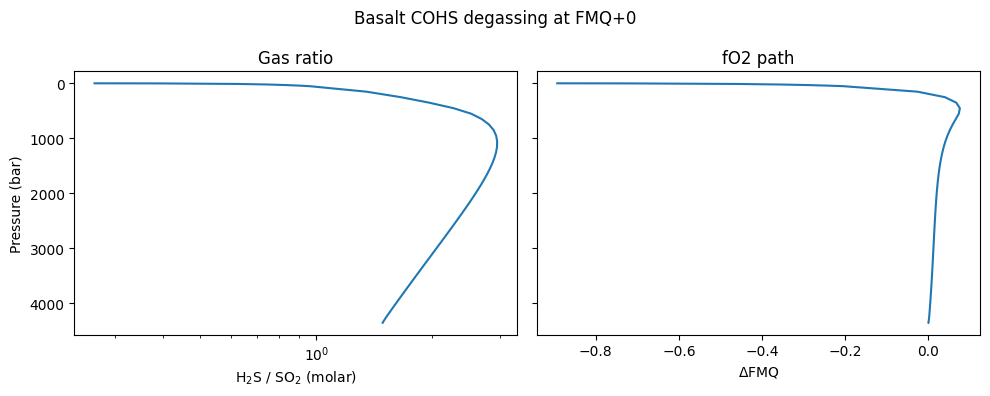

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# H2S/SO2 molar ratio — a proxy measurable at volcanic vents
axes[0].plot(df["mH2S/SO2"], df["P"])
axes[0].set_xlabel("H$_2$S / SO$_2$ (molar)")
axes[0].set_ylabel("Pressure (bar)")
axes[0].set_xscale("log")
axes[0].set_title("Gas ratio")

# fO2 relative to FMQ
axes[1].plot(df["FMQ"], df["P"])
axes[1].set_xlabel(r"$\Delta$FMQ")
axes[1].set_title("fO2 path")

# invert the axis
axes[0].invert_yaxis()
plt.suptitle("Basalt COHS degassing at FMQ+0")
plt.tight_layout()
plt.show()